# NEU steel defects - the split, the transforms and what they cost

Notebook 01 found what the two shipped folders contain. This one turns them into
the three sets the classifier needs, and measures each choice rather than
declaring it. This is module 04 of the Arkon platform, the Rolling Mill
department's multi-class vision module, feeding the classifier whose risk events
reach the Quality Steering Cell.

The dataset ships no test folder, only `train/` and `validation/`. This module
therefore splits the train folder for its own model selection and holds the
shipped `validation/` folder back as the test set, scored once in notebook 03.
Every count below says which folder it came from.

## 1. Imports and configuration

The shared helpers live in `notebooks/utils`. This cell puts that directory on the path.

In [1]:
import sys
from pathlib import Path

# notebooks/ holds the shared helpers; this notebook sits two levels below it
_nb_root = Path('../..').resolve()
if str(_nb_root) not in sys.path:
    sys.path.insert(0, str(_nb_root))

from utils.arkon_utils import save_figure

print('arkon_utils loaded')

arkon_utils loaded


The libraries and the configuration, written out here in full rather than imported
from anywhere. There is no training script for this module: notebook 03 is what
creates one, so these constants are the only definition of them that exists.

In [2]:
import copy
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from PIL import Image
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

plt.style.use('seaborn-v0_8-darkgrid')

ASSETS = 'cv'
RAW_DIR = Path('../../../data/04_neu/raw')
TRAIN_DIR = RAW_DIR / 'train' / 'images'
TEST_DIR = RAW_DIR / 'validation' / 'images'   # the shipped validation folder, held out as test

IMAGE_SIZE = 224          # the ImageNet backbone's input; the images are 200 x 200
BATCH_SIZE = 32
SEED = 42
VALIDATION_FRACTION = 0.15
ROTATION_DEGREES = 10

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

print(f'python      {sys.version.split()[0]}')
print(f'torch       {torch.__version__}')
print(f'train folder present: {TRAIN_DIR.is_dir()}   held-out folder present: {TEST_DIR.is_dir()}')

python      3.12.10
torch       2.6.0+cu124
train folder present: True   held-out folder present: True


## 2. The three sets, and which folder each comes from

`ImageFolder` reads the class from the directory name, which notebook 01 checked
against the bounding boxes: the folder class is never absent from an image's own
boxes, so it is a sound label. This cell loads both folders and prints what each
holds.

In [3]:
plain = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

train_folder = datasets.ImageFolder(TRAIN_DIR, transform=plain)
test_folder = datasets.ImageFolder(TEST_DIR, transform=plain)

CLASSES = train_folder.classes
print(f'classes ({len(CLASSES)}): {CLASSES}')
print(f'class to index: {train_folder.class_to_idx}')
print(f'the two folders agree on the class order: {train_folder.classes == test_folder.classes}')
print()
print(f'train folder                 {len(train_folder):,} images')
print(f'shipped validation folder    {len(test_folder):,} images, held back as the test set')

classes (6): ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
class to index: {'crazing': 0, 'inclusion': 1, 'patches': 2, 'pitted_surface': 3, 'rolled-in_scale': 4, 'scratches': 5}
the two folders agree on the class order: True

train folder                 1,440 images
shipped validation folder    360 images, held back as the test set


The class order is identical in both folders, which is not decoration: a model
trained on one index order and scored against the other would report a confusion
matrix that is a permutation of the truth, and nothing would raise.

## 3. Splitting the train folder, and whether it reproduces

The 1,440 training images are cut into a fitting set and a selection set. The cut
is stratified by class, because a random cut on six classes of 240 can hand one
class noticeably fewer than another and the operating point is chosen on this set.
The seed is fixed and the cell calls the function twice to check it.

In [4]:
def split_indices(targets, fraction, seed):
    """Stratified index split: hold back `fraction` of every class."""
    targets = np.asarray(targets)
    rng = np.random.default_rng(seed)
    held, kept = [], []
    for label in np.unique(targets):
        positions = np.flatnonzero(targets == label)
        rng.shuffle(positions)
        cut = int(round(len(positions) * fraction))
        held.extend(positions[:cut].tolist())
        kept.extend(positions[cut:].tolist())
    return sorted(kept), sorted(held)


targets = train_folder.targets
fit_index, selection_index = split_indices(targets, VALIDATION_FRACTION, SEED)
again_fit, again_selection = split_indices(targets, VALIDATION_FRACTION, SEED)

print(f'fitting set    {len(fit_index):,}')
print(f'selection set  {len(selection_index):,}')
print(f'they are disjoint and cover the folder: '
      f'{not set(fit_index) & set(selection_index) and len(fit_index) + len(selection_index) == len(targets)}')
print(f'a second call at the same seed returns the same split: '
      f'{fit_index == again_fit and selection_index == again_selection}')
print()

mix = pd.DataFrame({
    'fitting': pd.Series([targets[i] for i in fit_index]).value_counts().sort_index(),
    'selection': pd.Series([targets[i] for i in selection_index]).value_counts().sort_index(),
})
mix.index = [CLASSES[i] for i in mix.index]
mix['selection share'] = (mix['selection'] / (mix['fitting'] + mix['selection']) * 100).round(2)
print(mix.to_string())

fitting set    1,224
selection set  216
they are disjoint and cover the folder: True
a second call at the same seed returns the same split: True

                 fitting  selection  selection share
crazing              204         36             15.0
inclusion            204         36             15.0
patches              204         36             15.0
pitted_surface       204         36             15.0
rolled-in_scale      204         36             15.0
scratches            204         36             15.0


Every class contributes the same 36 images to the selection set, so the stratified
cut is exact rather than approximately balanced. That is a property of this dataset
being exactly balanced to begin with, and it means the selection set cannot
mislead through class drift.

Balance is not the only thing that can be wrong with a cut. Notebook 01 found one
pair of byte-identical images inside `train/patches`, and a plain stratified split
knows nothing about it. This cell asks which side each copy landed on.

In [5]:
train_paths = [Path(p).stem for p, _ in train_folder.samples]
duplicate_pair = {'patches_101', 'patches_105'}
where = {stem: ('fitting' if i in set(fit_index) else 'selection')
         for i, stem in enumerate(train_paths) if stem in duplicate_pair}
print(f'the duplicate pair notebook 01 found: {where}')
straddles = len(set(where.values())) > 1
print('the copies straddle the cut: one of the 216 selection images is a picture the model '
      'was fitted on' if straddles else
      'both copies are on the same side, so the cut is clean')

the duplicate pair notebook 01 found: {'patches_101': 'fitting', 'patches_105': 'selection'}
the copies straddle the cut: one of the 216 selection images is a picture the model was fitted on


**The copies straddle the cut, and unlike casting's leak this one is ours to
fix.** Casting's 64 overlapping images sit in a test folder the dataset published
and its model card can only qualify them. This pair is inside the train folder,
where the split is chosen here, so the honest move is not to report it but to
repair it.

The repair keeps the class counts exact: the selection-side copy is swapped with
an unrelated image of the same class from the fitting side, so both remain 204 and
36. It is deterministic and it is checked afterwards rather than assumed.

In [6]:
stem_at = {i: stem for i, stem in enumerate(train_paths)}
by_stem = {stem: i for i, stem in stem_at.items()}

fit_set, selection_set = set(fit_index), set(selection_index)
swapped = []
for stem in sorted(duplicate_pair):
    position = by_stem[stem]
    if position not in selection_set:
        continue
    label = train_folder.targets[position]
    # Take the lowest-indexed fitting image of the same class that is not itself a duplicate.
    partner = next(i for i in sorted(fit_set)
                   if train_folder.targets[i] == label and stem_at[i] not in duplicate_pair)
    selection_set.discard(position); fit_set.add(position)
    fit_set.discard(partner); selection_set.add(partner)
    swapped.append((stem, stem_at[partner]))

fit_index, selection_index = sorted(fit_set), sorted(selection_set)
for moved, replacement in swapped:
    print(f'moved {moved} into the fitting set, {replacement} into the selection set')

where_now = {stem: ('fitting' if by_stem[stem] in fit_set else 'selection') for stem in sorted(duplicate_pair)}
print(f'the pair after the repair: {where_now}')
print(f'both copies now on one side               : {len(set(where_now.values())) == 1}')
print(f'sets still disjoint and covering the folder: '
      f'{not fit_set & selection_set and len(fit_index) + len(selection_index) == len(targets)}')

mix = pd.DataFrame({
    'fitting': pd.Series([targets[i] for i in fit_index]).value_counts().sort_index(),
    'selection': pd.Series([targets[i] for i in selection_index]).value_counts().sort_index(),
})
mix.index = [CLASSES[i] for i in mix.index]
print(f'class counts still exactly balanced        : '
      f'{mix["fitting"].nunique() == 1 and mix["selection"].nunique() == 1} '
      f'({int(mix["fitting"].iloc[0])} / {int(mix["selection"].iloc[0])} per class)')

moved patches_105 into the fitting set, patches_1 into the selection set
the pair after the repair: {'patches_101': 'fitting', 'patches_105': 'fitting'}
both copies now on one side               : True
sets still disjoint and covering the folder: True
class counts still exactly balanced        : True (204 / 36 per class)


The selection set now holds no picture the model will have been fitted on, which
is what makes the operating point chosen on it worth anything.

The three sets, drawn.

  ✓ Saved → assets\cv\neu_prep_split.png


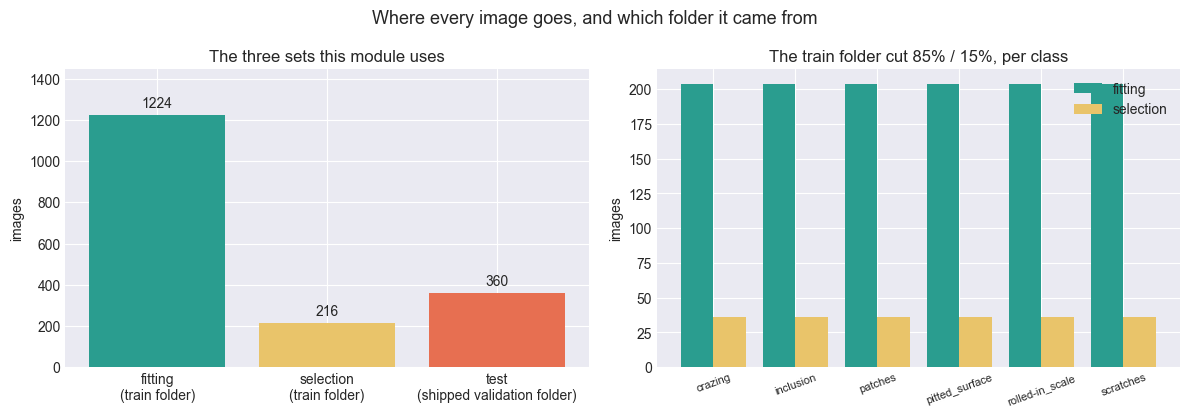

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
counts = [len(fit_index), len(selection_index), len(test_folder)]
labels = ['fitting\n(train folder)', 'selection\n(train folder)', 'test\n(shipped validation folder)']
bars = axes[0].bar(labels, counts, color=['#2a9d8f', '#e9c46a', '#e76f51'])
axes[0].bar_label(bars, fmt='%d', padding=3)
axes[0].set_ylabel('images')
axes[0].set_ylim(0, max(counts) * 1.18)
axes[0].set_title('The three sets this module uses')

positions = np.arange(len(CLASSES))
axes[1].bar(positions - 0.2, mix['fitting'], 0.4, label='fitting', color='#2a9d8f')
axes[1].bar(positions + 0.2, mix['selection'], 0.4, label='selection', color='#e9c46a')
axes[1].set_xticks(positions)
axes[1].set_xticklabels(CLASSES, rotation=20, fontsize=8)
axes[1].set_ylabel('images')
axes[1].legend()
axes[1].set_title(f'The train folder cut {1 - VALIDATION_FRACTION:.0%} / {VALIDATION_FRACTION:.0%}, per class')
fig.suptitle('Where every image goes, and which folder it came from', fontsize=13)
fig.tight_layout()
save_figure(fig, 'neu_prep_split', subfolder=ASSETS)
plt.show()

## 4. The normalisation, measured over the fitting set

The pipeline normalises with the ImageNet per-channel constants, which is standard
for a pretrained backbone. Notebook 01 found every image is greyscale in three
identical channels. This cell measures what those constants therefore do: three
copies of one number go in, and three different numbers come out.

In [8]:
loader = DataLoader(Subset(train_folder, fit_index), batch_size=64, shuffle=False)
total = torch.zeros(3)
total_square = torch.zeros(3)
pixels = 0
t0 = time.time()
for batch, _ in loader:
    total += batch.sum(dim=(0, 2, 3))
    total_square += (batch ** 2).sum(dim=(0, 2, 3))
    pixels += batch.shape[0] * batch.shape[2] * batch.shape[3]
dataset_mean = (total / pixels)
dataset_std = (total_square / pixels - dataset_mean ** 2).sqrt()
print(f'measured over {len(fit_index):,} fitting images in {time.time() - t0:.1f}s')
print(f'dataset mean  {[round(float(v), 4) for v in dataset_mean]}')
print(f'dataset std   {[round(float(v), 4) for v in dataset_std]}')
print(f'ImageNet mean {IMAGENET_MEAN}')
print(f'ImageNet std  {IMAGENET_STD}')
print()

after = [(float(dataset_mean[c]) - IMAGENET_MEAN[c]) / IMAGENET_STD[c] for c in range(3)]
print(f'the dataset mean after the ImageNet normalisation, per channel: '
      f'{[round(v, 4) for v in after]}')
print(f'spread introduced between three channels that were identical: '
      f'{max(after) - min(after):.4f}')
scaled = [float(dataset_std[c]) / IMAGENET_STD[c] for c in range(3)]
print(f'the scale it applies, dataset std over ImageNet std: {[round(v, 3) for v in scaled]}')

measured over 1,224 fitting images in 2.1s
dataset mean  [0.5042, 0.5042, 0.5042]
dataset std   [0.2063, 0.2063, 0.2063]
ImageNet mean [0.485, 0.456, 0.406]
ImageNet std  [0.229, 0.224, 0.225]

the dataset mean after the ImageNet normalisation, per channel: [0.084, 0.2154, 0.4366]
spread introduced between three channels that were identical: 0.3526
the scale it applies, dataset std over ImageNet std: [0.901, 0.921, 0.917]


**A fixed offset carrying no information, and a scale that is roughly right.** The
three channels enter identical and leave 0.36 apart, which is a constant added to
every image alike, so no class can be told from it and a convolution can absorb it.
The scale is the part that matters and it is close: the dataset's own spread is
within a fifth of the constants the backbone expects. The alternative, normalising
with the measured statistics above, would break the match with the pretrained
weights for a gain nothing here suggests exists.

Drawn: the three channels before the normalisation and after it.

  ✓ Saved → assets\cv\neu_prep_normalisation.png


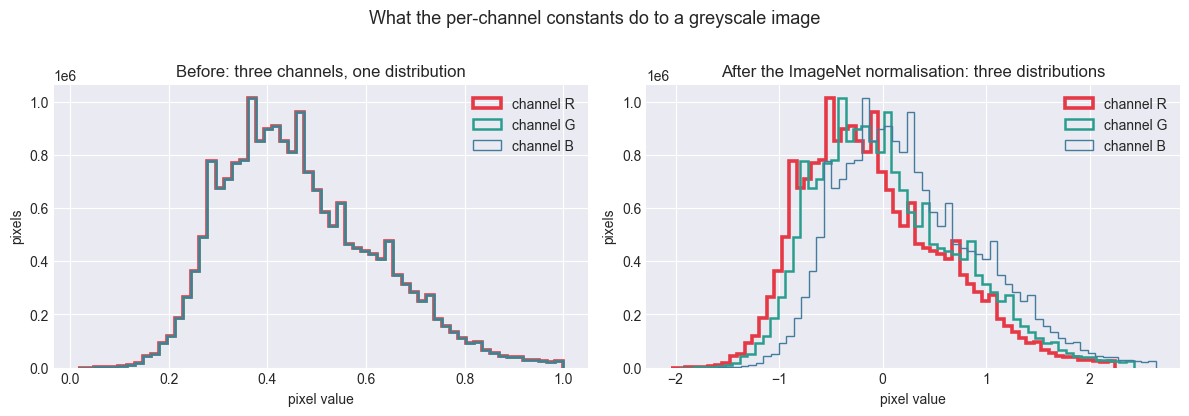

In [9]:
sample = torch.stack([train_folder[i][0] for i in fit_index[:400]])
before = sample.permute(1, 0, 2, 3).reshape(3, -1)
normalise = transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
after_tensor = normalise(sample).permute(1, 0, 2, 3).reshape(3, -1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for channel, colour, name in zip(range(3), ('#e63946', '#2a9d8f', '#457b9d'), 'RGB'):
    axes[0].hist(before[channel].numpy(), bins=60, histtype='step', color=colour,
                 label=f'channel {name}', linewidth=2.6 - channel * 0.8)
    axes[1].hist(after_tensor[channel].numpy(), bins=60, histtype='step', color=colour,
                 label=f'channel {name}', linewidth=2.6 - channel * 0.8)
axes[0].set_title('Before: three channels, one distribution')
axes[1].set_title('After the ImageNet normalisation: three distributions')
for ax in axes:
    ax.set_xlabel('pixel value')
    ax.set_ylabel('pixels')
    ax.legend()
fig.suptitle('What the per-channel constants do to a greyscale image', fontsize=13)
fig.tight_layout()
save_figure(fig, 'neu_prep_normalisation', subfolder=ASSETS)
plt.show()

## 5. Which augmentations are safe on rolled steel

Notebook 01 measured that the defect boxes are directional: `scratches` has a
median aspect ratio of 0.18 and `crazing` 1.80, so these classes differ in which
axis their texture runs along. That is a fact about the rolling direction, and it
decides the augmentation question. A mirror preserves which axis is which; a
quarter turn swaps them.

This cell measures the directionality of every fitting image directly, as the
imbalance between vertical and horizontal gradient energy, and checks whether the
six classes actually separate on it.

In [10]:
def directionality(array):
    """Positive when the texture runs across the image, negative when it runs down it."""
    gy = np.abs(np.diff(array, axis=0)).mean()
    gx = np.abs(np.diff(array, axis=1)).mean()
    return float((gy - gx) / (gy + gx + 1e-9))


rows = []
for index in fit_index:
    path, label = train_folder.samples[index]
    grey = np.asarray(Image.open(path).convert('L'), dtype=np.float32)
    rows.append({'class': CLASSES[label],
                 'direction': directionality(grey),
                 'direction_rot90': directionality(np.rot90(grey)),
                 'direction_hflip': directionality(grey[:, ::-1])})
direction = pd.DataFrame(rows)

summary = direction.groupby('class')[['direction', 'direction_rot90', 'direction_hflip']].mean()
print(summary.round(4).to_string())
print()
print(f'spread of the class means, as shipped        : '
      f'{summary["direction"].max() - summary["direction"].min():.4f}')
print(f'a horizontal mirror changes the class means by: '
      f'{(summary["direction_hflip"] - summary["direction"]).abs().max():.4f} at most')
print(f'a quarter turn changes them by                : '
      f'{(summary["direction_rot90"] - summary["direction"]).abs().max():.4f} at most')

                 direction  direction_rot90  direction_hflip
class                                                       
crazing            -0.0335           0.0335          -0.0335
inclusion          -0.0766           0.0766          -0.0766
patches            -0.0603           0.0603          -0.0603
pitted_surface     -0.0761           0.0761          -0.0761
rolled-in_scale     0.1039          -0.1039           0.1039
scratches          -0.1862           0.1862          -0.1862

spread of the class means, as shipped        : 0.2901
a horizontal mirror changes the class means by: 0.0000 at most
a quarter turn changes them by                : 0.3724 at most


**The classes separate on direction, a mirror leaves it alone, and a quarter turn
destroys it.** So the two flips are free and a 90 degree rotation is not an
augmentation here but a relabelling of the texture axis. The transform below uses
both flips and a small rotation only, and the next cell measures what even that
small rotation costs.

In [11]:
resize = transforms.Resize((IMAGE_SIZE, IMAGE_SIZE))
to_tensor = transforms.ToTensor()
base = [to_tensor(resize(Image.open(train_folder.samples[i][0]).convert('RGB')))
        for i in fit_index[:300]]
stacked = torch.stack(base)

candidates = {
    'horizontal flip': transforms.RandomHorizontalFlip(p=1.0),
    'vertical flip': transforms.RandomVerticalFlip(p=1.0),
    f'rotation {ROTATION_DEGREES} deg': transforms.RandomRotation(ROTATION_DEGREES),
    'quarter turn': transforms.RandomRotation((90, 90)),
}

torch.manual_seed(SEED)
# How far a different picture sits, as the yardstick every augmentation is read against.
shuffled = stacked[torch.randperm(len(stacked))]
other_image = (stacked - shuffled).abs().mean().item()

print(f'{"transform":<22}{"moves":>10}{"vs another image":>19}{"frame blacked out":>20}')
for name, transform in candidates.items():
    moved = torch.stack([transform(image) for image in stacked])
    distance = (stacked - moved).abs().mean().item()
    black = (moved.sum(dim=1) == 0).float().mean().item()
    print(f'{name:<22}{distance:>10.4f}{distance / other_image:>18.0%}{black:>19.1%}')
print(f'{"a different image":<22}{other_image:>10.4f}{1.0:>18.0%}{0.0:>19.1%}')

transform                  moves   vs another image   frame blacked out
horizontal flip           0.1097               62%               0.0%


vertical flip             0.0699               40%               0.0%


rotation 10 deg           0.0664               38%               3.9%


quarter turn              0.0983               56%               0.0%
a different image         0.1761              100%               0.0%


The flips move an image a large fraction of the way towards a different picture
and cost nothing, which is what an augmentation should do. The small rotation moves
it less and pays for it by blacking out part of the frame, and the quarter turn is
listed only to show its size: it is excluded on the directionality measurement
above, not on its distance.

One image under five draws of the chosen training transform, beside the measured
distances.

  ✓ Saved → assets\cv\neu_prep_augmentation.png


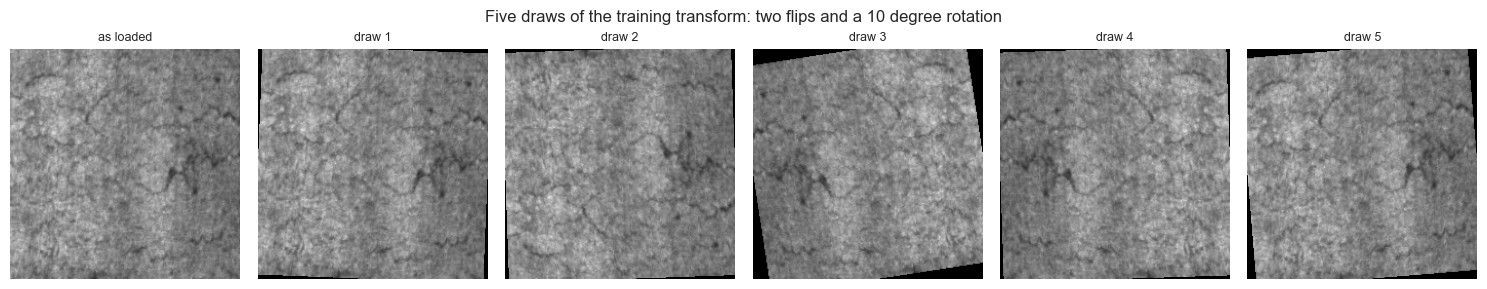

In [12]:
TRAIN_TRANSFORM = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(ROTATION_DEGREES),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

EVAL_TRANSFORM = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

torch.manual_seed(SEED)
example = Image.open(train_folder.samples[fit_index[7]][0]).convert('RGB')
mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
std = torch.tensor(IMAGENET_STD).view(3, 1, 1)

fig, axes = plt.subplots(1, 6, figsize=(15, 2.9))
axes[0].imshow(np.asarray(resize(example)), cmap='gray')
axes[0].set_title('as loaded', fontsize=9)
for column in range(1, 6):
    drawn = TRAIN_TRANSFORM(example) * std + mean
    axes[column].imshow(drawn.permute(1, 2, 0).clamp(0, 1).numpy(), cmap='gray')
    axes[column].set_title(f'draw {column}', fontsize=9)
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle('Five draws of the training transform: two flips and a 10 degree rotation', fontsize=12)
fig.tight_layout()
save_figure(fig, 'neu_prep_augmentation', subfolder=ASSETS)
plt.show()

## 6. Two subsets of one folder, two different transforms

The fitting and selection sets are two index lists over a single `ImageFolder`
object, and they need different transforms: augmentation on one, none on the other.
Setting `.transform` through a `Subset` reaches the shared parent and changes both.
This cell builds the pair the way that avoids it, and then checks the result rather
than trusting it.

In [13]:
augmented = copy.copy(train_folder)
augmented.transform = TRAIN_TRANSFORM
evaluated = copy.copy(train_folder)
evaluated.transform = EVAL_TRANSFORM
test_folder.transform = EVAL_TRANSFORM

print(f'the two views are separate objects        : {augmented is not evaluated}')
print(f'they share the sample list                : {augmented.samples is evaluated.samples}')
print(f'the fitting view augments                 : {augmented.transform is TRAIN_TRANSFORM}')
print(f'the selection view does not               : {evaluated.transform is EVAL_TRANSFORM}')
print()

# The check that matters: the same index through both views must differ, and the
# evaluation view must be repeatable.
torch.manual_seed(SEED)
a1, _ = augmented[fit_index[0]]
a2, _ = augmented[fit_index[0]]
e1, _ = evaluated[fit_index[0]]
e2, _ = evaluated[fit_index[0]]
print(f'two reads of the augmenting view differ   : {not torch.equal(a1, a2)}')
print(f'two reads of the evaluation view are equal: {torch.equal(e1, e2)}')
print(f'the two views disagree on the same image  : {not torch.equal(a1, e1)}')

the two views are separate objects        : True
they share the sample list                : True
the fitting view augments                 : True
the selection view does not               : True

two reads of the augmenting view differ   : True
two reads of the evaluation view are equal: True
the two views disagree on the same image  : True


Had the transform been set through the `Subset`, the third line would still read
True while the augmentation was silently switched off for the fitting set as well.
The construction is what prevents it, not the outcome, so all four lines are
printed.

## 7. The three loaders, and one batch pulled through

The loaders as notebook 03 will build them. Shuffling is on for fitting only; the
two evaluation loaders keep folder order so a prediction table lines up with the
file list that produced it.

fitting     1,224 images in  39 batches of at most 32
selection     216 images in   7 batches of at most 32
test          360 images in  12 batches of at most 32

one batch: (32, 3, 224, 224), dtype torch.float32
value range after normalisation: -2.118 to 2.640
labels in it: ['pitted_surface', 'inclusion', 'scratches', 'crazing', 'crazing', 'pitted_surface', 'scratches', 'patches']


  ✓ Saved → assets\cv\neu_prep_batch.png


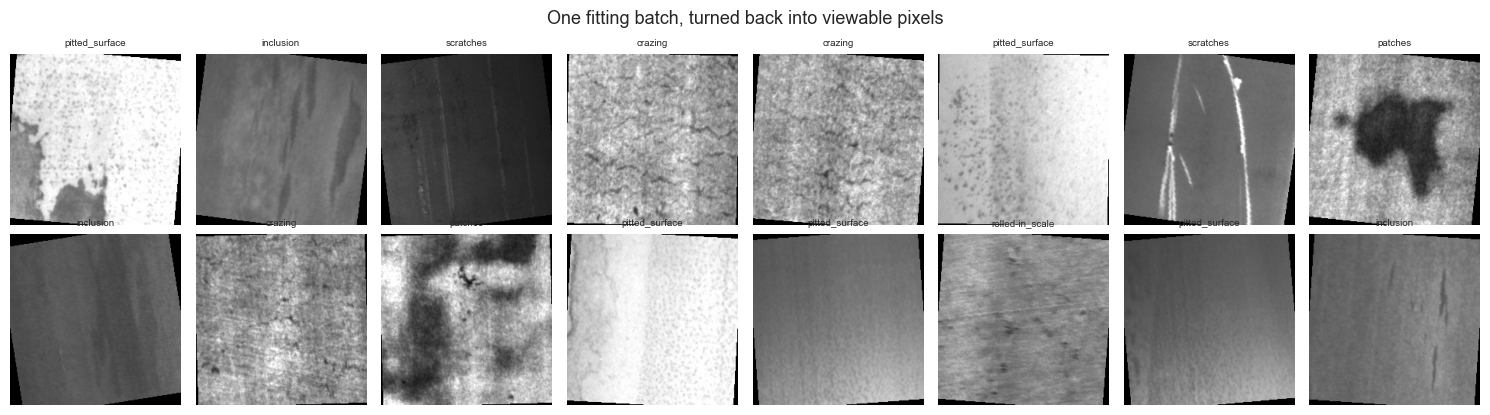

In [14]:
fit_loader = DataLoader(Subset(augmented, fit_index), batch_size=BATCH_SIZE,
                        shuffle=True, num_workers=0)
selection_loader = DataLoader(Subset(evaluated, selection_index), batch_size=BATCH_SIZE,
                              shuffle=False, num_workers=0)
test_loader = DataLoader(test_folder, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

for name, loader in (('fitting', fit_loader), ('selection', selection_loader), ('test', test_loader)):
    print(f'{name:<11}{len(loader.dataset):>6,} images in {len(loader):>3} batches of at most {BATCH_SIZE}')
print()

torch.manual_seed(SEED)
batch, labels = next(iter(fit_loader))
print(f'one batch: {tuple(batch.shape)}, dtype {batch.dtype}')
print(f'value range after normalisation: {batch.min():.3f} to {batch.max():.3f}')
print(f'labels in it: {[CLASSES[i] for i in labels[:8].tolist()]}')

fig, axes = plt.subplots(2, 8, figsize=(15, 4.2))
for ax, image, label in zip(axes.ravel(), batch, labels):
    ax.imshow((image * std + mean).permute(1, 2, 0).clamp(0, 1).numpy(), cmap='gray')
    ax.set_title(CLASSES[label], fontsize=7)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle('One fitting batch, turned back into viewable pixels', fontsize=13)
fig.tight_layout()
save_figure(fig, 'neu_prep_batch', subfolder=ASSETS)
plt.show()

## 8. What this notebook found

In [15]:
print(f'1. The train folder is cut {len(fit_index):,} / {len(selection_index):,} stratified at seed '
      f'{SEED}, exactly {int(mix["selection"].iloc[0])} images per class held for selection, '
      f'and a second call reproduces it.')
print(f'2. The shipped validation folder, {len(test_folder)} images, is the test set. It is not '
      f'touched again until notebook 03 scores it once.')
print(f'3. The ImageNet constants push three identical channels {max(after) - min(after):.4f} apart, '
      f'a constant offset no class can be told from; the scale they apply is within '
      f'{max(abs(1 - v) for v in scaled):.0%} of the dataset\'s own.')
print(f'4. The six classes separate on texture direction over a range of '
      f'{summary["direction"].max() - summary["direction"].min():.3f}. A mirror leaves that '
      f'untouched and a quarter turn inverts it, so the augmentation is two flips and a '
      f'{ROTATION_DEGREES} degree rotation.')
print(f'5. The duplicate pair from notebook 01 straddled the cut, putting a fitted image into the '
      f'selection set. It was repaired by a same-class swap, and both copies now sit in the '
      f'{sorted(set(where_now.values()))[0]} set with the class counts unchanged.')

1. The train folder is cut 1,224 / 216 stratified at seed 42, exactly 36 images per class held for selection, and a second call reproduces it.
2. The shipped validation folder, 360 images, is the test set. It is not touched again until notebook 03 scores it once.
3. The ImageNet constants push three identical channels 0.3526 apart, a constant offset no class can be told from; the scale they apply is within 10% of the dataset's own.
4. The six classes separate on texture direction over a range of 0.290. A mirror leaves that untouched and a quarter turn inverts it, so the augmentation is two flips and a 10 degree rotation.
5. The duplicate pair from notebook 01 straddled the cut, putting a fitted image into the selection set. It was repaired by a same-class swap, and both copies now sit in the fitting set with the class counts unchanged.
